In [38]:
!pip install gensim

In [39]:
!pip install plotly kaleido -q

In [40]:
import pynvml
pynvml.nvmlInit()
handle = pynvml.nvmlDeviceGetHandleByIndex(0)
info = pynvml.nvmlDeviceGetMemoryInfo(handle)
print(f"Total memory: {info.total / 1024**2} MB")
print(f"Free memory: {info.free / 1024**2} MB")
print(f"Used memory: {info.used / 1024**2} MB")

Total memory: 15360.0 MB
Free memory: 14912.6875 MB
Used memory: 447.3125 MB


In [41]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from gensim.models import Word2Vec
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff

In [42]:
import cudf
from cuml.decomposition import PCA as cumlPCA
from cuml.manifold import TSNE as cumlTSNE
import numpy as np

In [58]:
import kagglehub
path = kagglehub.dataset_download("gpreda/elon-musk-tweets")

Using Colab cache for faster access to the 'elon-musk-tweets' dataset.


In [60]:
df = pd.read_csv("/kaggle/input/elon-musk-tweets/elon_musk_tweets.csv")
df.head()

,id,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,text,hashtags,source,retweets,favorites,is_retweet
0,1544379368478212100,Elon Musk,NaN,"Mars & Cars, Chips & Dips",2009-06-02 20:12:29+00:00,101240855,115,13503,True,2022-07-05 17:55:09+00:00,@BillyM2k I find the gold toe sock – inevitabl...,NaN,Twitter for iPhone,335,6542,False
1,1544377493263720450,Elon Musk,NaN,"Mars & Cars, Chips & Dips",2009-06-02 20:12:29+00:00,101240806,115,13503,True,2022-07-05 17:47:42+00:00,"Sock Con, the conference for socks",NaN,Twitter for iPhone,1451,30753,False
2,1544377130590552064,Elon Musk,NaN,"Mars & Cars, Chips & Dips",2009-06-02 20:12:29+00:00,101240806,115,13503,True,2022-07-05 17:46:15+00:00,Always something new for the magazine cover an...,NaN,Twitter for iPhone,1284,28610,False
3,1544375575724400645,Elon Musk,NaN,"Mars & Cars, Chips & Dips",2009-06-02 20:12:29+00:00,101240806,115,13503,True,2022-07-05 17:40:05+00:00,@ExplainThisBob This guy gets it,NaN,Twitter for iPhone,131,3640,False
4,1544375148605853699,Elon Musk,NaN,"Mars & Cars, Chips & Dips",2009-06-02 20:12:29+00:00,101240806,115,13503,True,2022-07-05 17:38:23+00:00,Sock tech is so advanced that you can get pret...,NaN,Twitter for iPhone,1191,23790,False


In [62]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
corpus = df.text
corpus = [" ".join([word for word in text.lower().split() if word not in ENGLISH_STOP_WORDS]) for text in corpus]

In [63]:
vectorizer = CountVectorizer(binary=True, stop_words='english')
X_onehot = vectorizer.fit_transform(corpus).toarray()
df_onehot = pd.DataFrame(X_onehot, columns=vectorizer.get_feature_names_out())
df_onehot

,000,008zpnmegm,01fmxyrrvr,01gvguwxyp,02100_eth,04efhdxate,04lop7jcum,08uwdnmpd7,0bahv9j2tt,0ecpd30qas,...,zqqnolhcdn,zssbecker,zswitten,zubymusic,zuck,zutcsd7fiz,zuuy1szjud,zydrar6mxf,zyrvfjywo4,秦始皇
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5899,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5900,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5901,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5902,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [64]:
vectorizer_bow = CountVectorizer(stop_words='english')
X_bow = vectorizer_bow.fit_transform(corpus).toarray()
df_bow = pd.DataFrame(X_bow, columns=vectorizer_bow.get_feature_names_out())
df_bow

,000,008zpnmegm,01fmxyrrvr,01gvguwxyp,02100_eth,04efhdxate,04lop7jcum,08uwdnmpd7,0bahv9j2tt,0ecpd30qas,...,zqqnolhcdn,zssbecker,zswitten,zubymusic,zuck,zutcsd7fiz,zuuy1szjud,zydrar6mxf,zyrvfjywo4,秦始皇
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5899,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5900,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5901,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5902,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [65]:
vectorizer_tfidf = TfidfVectorizer(stop_words='english')
X_tfidf = vectorizer_tfidf.fit_transform(corpus).toarray()
df_tfidf = pd.DataFrame(X_tfidf, columns=vectorizer_tfidf.get_feature_names_out())
df_tfidf

,000,008zpnmegm,01fmxyrrvr,01gvguwxyp,02100_eth,04efhdxate,04lop7jcum,08uwdnmpd7,0bahv9j2tt,0ecpd30qas,...,zqqnolhcdn,zssbecker,zswitten,zubymusic,zuck,zutcsd7fiz,zuuy1szjud,zydrar6mxf,zyrvfjywo4,秦始皇
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5899,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5900,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5901,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5902,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [66]:
# GPU-accelerated heatmap with Plotly (faster rendering)
fig = ff.create_annotated_heatmap(z=X_bow[:100, :100], colorscale='Viridis', showscale=True)
fig.update_layout(title="Bag of Words Heatmap (GPU-Accelerated)")
fig.show()

In [67]:
# GPU-accelerated heatmap with Plotly (faster rendering)
fig = ff.create_annotated_heatmap(z=X_tfidf[:100, :100], colorscale='Viridis', showscale=True)
fig.update_layout(title="TF-IDF Heatmap (GPU-Accelerated)")
fig.show()

In [68]:
from sklearn.decomposition import PCA
from gensim.models import Word2Vec
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

tokenized_corpus = [[word for word in text.lower().split() if word not in ENGLISH_STOP_WORDS] for text in corpus]

word2vec_model = Word2Vec(sentences=tokenized_corpus, vector_size=100, window=5, min_count=1, workers=4)

words = list(word2vec_model.wv.index_to_key)
vectors = word2vec_model.wv[words]

pca = PCA(n_components=2)
reduced = pca.fit_transform(vectors)

fig = go.Figure()
fig.add_trace(go.Scatter(x=reduced[:, 0], y=reduced[:, 1], mode='markers+text',
                         text=words, textposition="top center",
                         marker=dict(size=8, color=list(range(len(words))), colorscale='Viridis')))
fig.update_layout(title="Word2Vec PCA Projection (Plotly)", xaxis_title="PC1", yaxis_title="PC2")
fig.show()

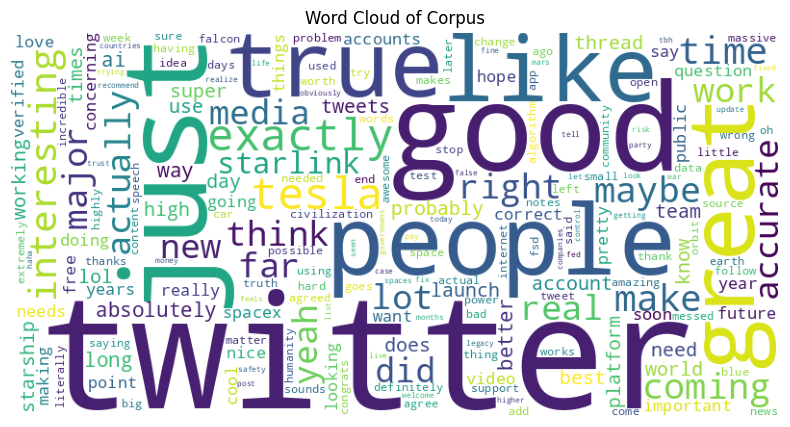

In [69]:
from wordcloud import WordCloud
full_text = " ".join(corpus).lower()
word_freq = {word: full_text.split().count(word) for word in vectorizer_bow.get_feature_names_out()}
wc = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)
plt.figure(figsize=(10, 5))
plt.imshow(wc)
plt.axis('off')
plt.title('Word Cloud of Corpus')
plt.show()

In [70]:
from cuml.manifold import TSNE as cumlTSNE
tsne_gpu = cumlTSNE(n_components=2, perplexity=5, random_state=42, learning_rate=200)
reduced_tsne_gpu = tsne_gpu.fit_transform(np.array(vectors))

# GPU-accelerated visualization with Plotly
fig = go.Figure()
fig.add_trace(go.Scatter(x=reduced_tsne_gpu[:, 0], y=reduced_tsne_gpu[:, 1], mode='markers+text',
                         text=words[:100], textposition="top center",
                         marker=dict(size=8, color=list(range(100)), colorscale='Viridis')))
fig.update_layout(title="GPU Accelerated Word2Vec t-SNE Projection (cuML + Plotly)",
                  xaxis_title="t-SNE 1", yaxis_title="t-SNE 2")
fig.show()